In [64]:
# imports
from pathlib import Path

from PIL import Image
import pandas as pd
import numpy as np
import seaborn as sns
from spc_spectra import spc
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

from functions.Clustering import cluster_pca, cluster_tsne, cluster_kmeans, classify_svm
from functions.CNN import train_simple_cnn, train_pretrained_cnn, train_vgg16_cnn
from functions.ImageEncoder import image_encoder, spider_image_encoder

# Analysis of Palm-Leaf Manuscripts
Data: https://doi.org/10.25592/uhhfdm.16468

## Binary classification of the species

*Corypha umbraculifera*:
35-3208, 35-3188, 35-3363 (measured twice)

*Borassus flabellifer*:
35-3028, 35-3009, 35-3169, 35-3299, 35-3110, 35-3112, 35-3011, 35-3005, 35-3008, 35-3024, 35-3033, 35-3051, 35-3209, 35-3170

For the species the classes are unbalanced. For now, we just use the same amount of datapoints for each class.

In [2]:
def _snv_1d(y: np.ndarray) -> np.ndarray:
    y = np.asarray(y, dtype=float)
    s = y.std(ddof=0)
    if s == 0:
        return y * 0.0
    return (y - y.mean()) / s

In [3]:
def load_spc_folder_to_df(
    data_dir: str | Path,
    file_glob: str = "**/*.spc",   # recursive!
    x_grid: np.ndarray | None = None,
    x_round: int = 3,
    keep_x_order: bool = True,     # keep as stored in file (often descending in IR)
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Reads all .spc files under data_dir (including subfolders) and returns:
      df: rows=spectra, cols=wavenumber
      meta: filename + relative path
    """
    data_dir = Path(data_dir)
    if not data_dir.exists():
        raise FileNotFoundError(f"Folder not found: {data_dir.resolve()}")

    files = sorted(data_dir.glob(file_glob))
    if not files:
        raise FileNotFoundError(f"No files matched {file_glob} in {data_dir.resolve()}")

    xs, ys, meta_rows = [], [], []
    for fp in files:
        s = spc.File(str(fp))
        x = np.asarray(s.x, dtype=float)

        # one spectrum per file:
        if hasattr(s, "sub") and len(s.sub) > 0:
            y = np.asarray(s.sub[0].y, dtype=float)
        else:
            y = np.asarray(getattr(s, "y"), dtype=float)

        xs.append(x)
        ys.append(y)
        meta_rows.append(
            {
                "rel_path": str(fp.relative_to(data_dir)),
                "filename": fp.name,
            }
        )

    # If no shared x_grid provided, pick the first file's x as "master"
    # (works if all files share the same wavenumbers)
    if x_grid is None:
        x_grid = xs[0]

    x_grid = np.asarray(x_grid, dtype=float)

    # Interpolate each spectrum onto x_grid if needed
    spectra = []
    for x, y in zip(xs, ys):
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)

        if np.array_equal(x, x_grid):
            y_i = y
        else:
            # For interpolation, x must be increasing
            order = np.argsort(x)
            x_sorted = x[order]
            y_sorted = y[order]

            xg = x_grid
            if keep_x_order and (len(xg) > 1) and (xg[0] > xg[-1]):  # descending grid
                xg_sorted = np.sort(xg)
                y_interp_sorted = np.interp(xg_sorted, x_sorted, y_sorted)
                # map back to descending order
                y_i = y_interp_sorted[::-1]
            else:
                xg_sorted = np.sort(xg)
                y_i = np.interp(xg_sorted, x_sorted, y_sorted)
                if keep_x_order and (len(xg) > 1) and (xg[0] > xg[-1]):
                    y_i = y_i[::-1]

        spectra.append(y_i)

    # Column names = wavenumbers (rounded) in the same order as x_grid
    cols = np.round(x_grid, x_round)
    df = pd.DataFrame(spectra, columns=cols)
    meta = pd.DataFrame(meta_rows)

    return df, meta

In [4]:
df_raw_corypha, meta_corypha = load_spc_folder_to_df("Data/species/Corypha")
df_raw_borassus, meta_borassus = load_spc_folder_to_df("Data/species/Borassus")

# df_raw.shape

gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)
gx-y(1)


In [8]:
# Balanced concat: sample to smallest size, then concat
n = min(len(df_raw_corypha), len(df_raw_borassus))

df_raw_corypha_bal = df_raw_corypha.sample(n=250, random_state=42)
df_raw_borassus_bal = df_raw_borassus.sample(n=250, random_state=42)

df_raw = pd.concat([df_raw_corypha_bal, df_raw_borassus_bal], ignore_index=True)
df_raw.shape

(500, 1799)

In [9]:
def snv_df(df: pd.DataFrame) -> pd.DataFrame:
    X = df.to_numpy(dtype=float)
    mean = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1, keepdims=True)
    std[std == 0] = 1.0
    Y = (X - mean) / std
    return pd.DataFrame(Y, columns=df.columns, index=df.index)

In [10]:
def make_derivatives_savgol(
    df: pd.DataFrame,
    window: int = 11,
    poly: int = 2,
    trim: int = 0,
) -> dict[str, pd.DataFrame]:
    if window % 2 == 0:
        window += 1

    X = df.to_numpy(dtype=float)

    d0 = savgol_filter(X, window_length=window, polyorder=poly, deriv=0, axis=1)
    d1 = savgol_filter(X, window_length=window, polyorder=poly, deriv=1, axis=1)
    d2 = savgol_filter(X, window_length=window, polyorder=poly + 1, deriv=2, axis=1)
    d3 = savgol_filter(X, window_length=window, polyorder=poly + 2, deriv=3, axis=1)

    out = {
        "raw": pd.DataFrame(d0, columns=df.columns, index=df.index),
        "d1":  pd.DataFrame(d1, columns=df.columns, index=df.index),
        "d2":  pd.DataFrame(d2, columns=df.columns, index=df.index),
        "d3":  pd.DataFrame(d3, columns=df.columns, index=df.index),
    }
    if trim > 0:
        for k in out:
            out[k] = out[k].iloc[:, trim:-trim]
    return out


In [11]:
df_snv = snv_df(df_raw)
data = make_derivatives_savgol(df_snv, window=11, poly=2, trim=12)

{k: v.shape for k, v in data.items()}

{'raw': (500, 1775), 'd1': (500, 1775), 'd2': (500, 1775), 'd3': (500, 1775)}

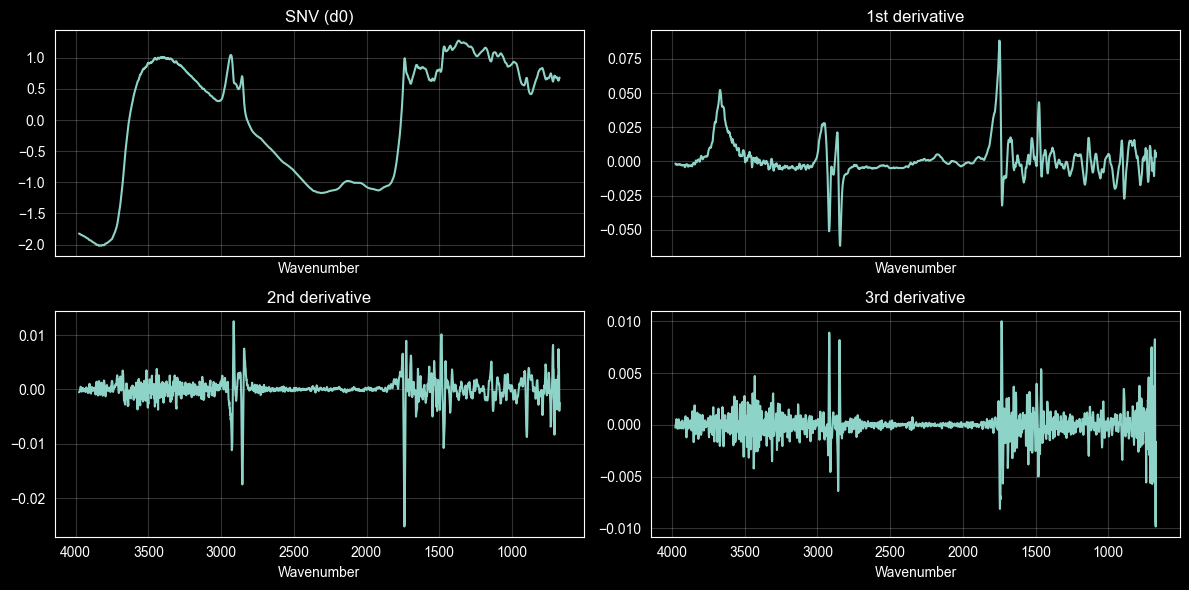

In [12]:
i = 0  # spectrum index to inspect
fig, ax = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
ax = ax.ravel()

ax[0].plot(data["raw"].columns, data["raw"].iloc[i].values)
ax[0].set_title("SNV (d0)")

ax[1].plot(data["d1"].columns, data["d1"].iloc[i].values)
ax[1].set_title("1st derivative")

ax[2].plot(data["d2"].columns, data["d2"].iloc[i].values)
ax[2].set_title("2nd derivative")

ax[3].plot(data["d3"].columns, data["d3"].iloc[i].values)
ax[3].set_title("3rd derivative")

for a in ax:
    a.grid(True, alpha=0.2)
    a.xaxis.set_inverted(True)
    a.set_xlabel("Wavenumber")

plt.tight_layout()
plt.show()

# Clustering and Classification

These use the functions from the Test Application for now.

In [26]:
labels = ["Corypha"] * 250 + ["Borassus"] * 250
labels_generic = ["First Class"] * 250 + ["Second Class"] * 250

Total explained variance by first two components: 57.5%


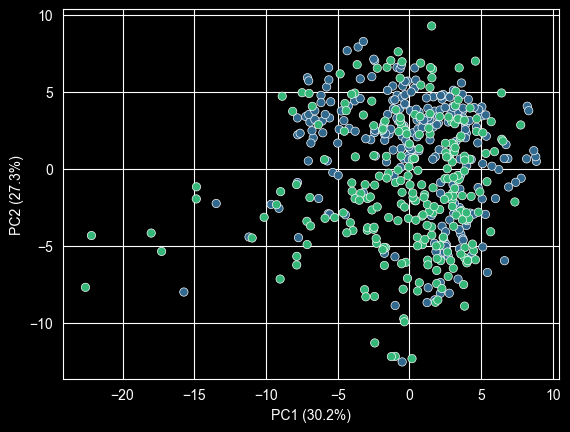

In [22]:
# PCA
pca_df, pca_var = cluster_pca(data["raw"], labels)

fig_pca, ax_pca = plt.subplots()
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Class", palette="viridis", legend=False, ax=ax_pca)
var = pca_var
ax_pca.set_xlabel(f"PC1 ({var[0]:.1%})")
ax_pca.set_ylabel(f"PC2 ({var[1]:.1%})")
print(f"Total explained variance by first two components: {sum(var):.1%}")

<Axes: xlabel='TSNE1', ylabel='TSNE2'>

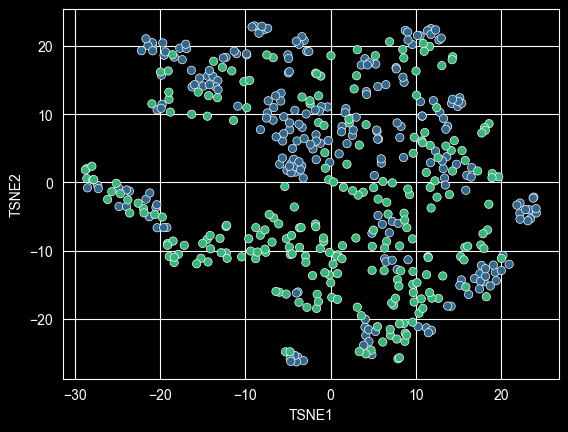

In [23]:
tsne_df = cluster_tsne(data["raw"], labels)

fig_tsne, ax_tsne = plt.subplots()
sns.scatterplot(data=tsne_df, x="TSNE1", y="TSNE2", hue="Class", palette="viridis", legend=False, ax=ax_tsne)

Predicted Cluster,Cluster 0 (First Class),Cluster 1 (Second Class)
Actual Class,,
First Class,148,102
Second Class,102,148


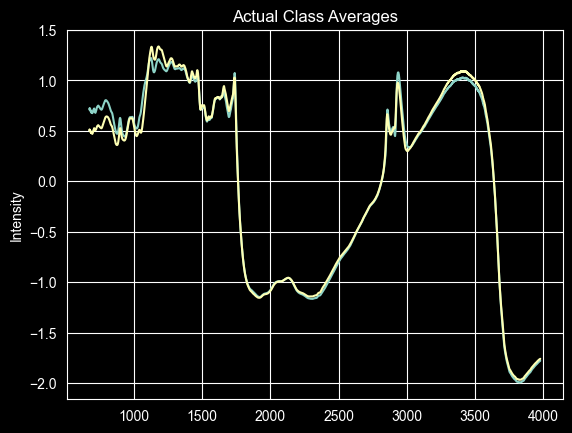

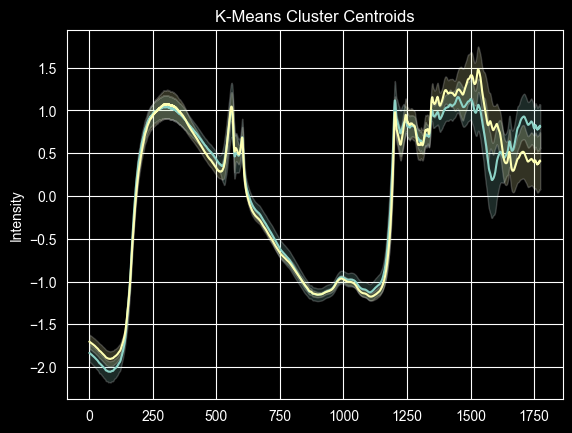

In [33]:
# K-means

kmeans_result = cluster_kmeans(data["raw"], labels_generic, n_clusters=2)

actual_means, (pred_means, pred_stds), confusion_matrix, metrics = kmeans_result

fig_act, ax_act = plt.subplots()
sns.lineplot(data=actual_means.T, legend=False, ax=ax_act, dashes=False)
ax_act.set_title("Actual Class Averages")
ax_act.set_ylabel("Intensity")

fig_pred, ax_pred = plt.subplots()
for i, cluster_name in enumerate(pred_means.index):
    mean_curve = pred_means.loc[cluster_name]
    std_curve = pred_stds.loc[cluster_name]
    x_vals = range(len(mean_curve))
    # Plot the main line
    ax_pred.plot(x_vals, mean_curve, label=cluster_name)
    # Plot the variation area
    ax_pred.fill_between(x_vals,
                         mean_curve - std_curve,
                         mean_curve + std_curve,
                         alpha=0.2)
    ax_pred.set_title("K-Means Cluster Centroids")
    ax_pred.set_ylabel("Intensity")

confusion_matrix

In [48]:
# SVM
svm_train, svm_test, cm_train, cm_test = classify_svm(data["raw"], labels_generic, c=1)
svm_train_d1, svm_test_d1, cm_train_d1, cm_test_d1 = classify_svm(data["d1"], labels_generic, c=1)

In [51]:
cm_train

Predicted,First Class,Second Class
Actual,,
First Class,162,13
Second Class,30,145


In [52]:
cm_test

Predicted,First Class,Second Class
Actual,,
First Class,65,10
Second Class,18,57


# Image Encoding


In [57]:
for conv in ["BW", "RGB", "HSV"]:
    path_c = "Data/img/"+conv+"/corypha/"
    path_b = "Data/img/"+conv+"/borassus/"
    for i in range(len(data["raw"])):
        img = image_encoder(data, ['raw','d1','d2'], i, conv)
        if i < 250:
            img.convert('RGB').save((path_c+'img_'+str(i)+'.png'), format='PNG')
        else:
            img.convert('RGB').save((path_b+'img_'+str(i)+'.png'), format='PNG')


In [61]:
for i in range(len(data["raw"])):
    img = spider_image_encoder(data, ['raw','d1'], "HSV", i, margin=1)
    if i < 250:
        img.save(('Data/img/spider_h/corypha/img_'+str(i)+'.png'), format='PNG')
    else:
        img.save(('Data/img/spider_h/borassus/img_'+str(i)+'.png'), format='PNG')

# CNN Model

In [115]:
# Load all images from folder into a list (including subdirectories)
image_paths = sorted(Path("Data/img/HSV").rglob("*.png"))
loaded_images = [Image.open(p) for p in image_paths]

In [124]:
model, history, results = train_simple_cnn(loaded_images, labels_generic, epochs=20, batch_size=16)
train_m, test_m, train_cnn_cm, test_cnn_cm = results

In [125]:
test_cnn_cm

,Pred First,Pred Second
Actual First,73,0
Actual Second,77,0


In [107]:
model, history, results = train_pretrained_cnn(loaded_images, labels_generic, epochs=20, batch_size=16)
train_m, test_m, train_cnn_cm, test_cnn_cm = results

2026-01-25 18:59:47.873 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


/Users/filipo/Documents/NeueFische/Capstone/GitProject/.venv/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [108]:
test_cnn_cm

,Pred First,Pred Second
Actual First,65,8
Actual Second,22,55


# Spider

In [113]:
model, history, results = train_vgg16_cnn(loaded_images, labels_generic, epochs=30, batch_size=16)
train_m, test_m, train_cnn_cm, test_cnn_cm = results

Images already right size. Skipping resize.


In [114]:
test_cnn_cm

,Pred First,Pred Second
Actual First,43,23
Actual Second,10,74
